# Demo: flujo de delegación del orquestador multi-agente

Pedido de prueba: *¿Qué tanto encaja mi perfil con el puesto de AI Engineer en Pampa AI y qué me falta?*

Recorrido esperado: **Supervisor → Investigador → Supervisor → Analista → Supervisor → Validador → Síntesis → END**.

In [1]:
import logging
from IPython.display import Image, display

from graph import construir_grafo_del_orquestador
from main import configurar_registro_en_consola_y_archivo, ejecutar_orquestador_y_registrar_la_delegacion, PEDIDO_DE_PRUEBA

configurar_registro_en_consola_y_archivo()
logging.getLogger('google_genai').setLevel(logging.WARNING)

## 1. El grafo

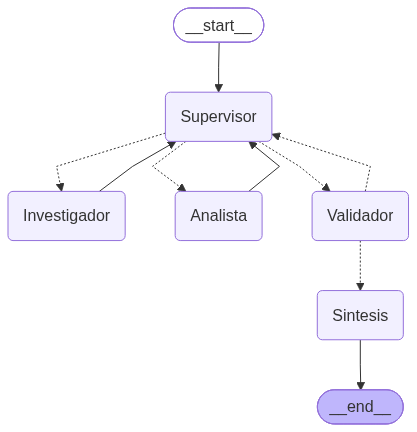

In [2]:
display(Image(construir_grafo_del_orquestador().compile().get_graph().draw_mermaid_png()))

## 2. Ejecución: cada línea muestra qué nodo actuó y qué decidió

In [3]:
pasos_de_la_delegacion = await ejecutar_orquestador_y_registrar_la_delegacion(PEDIDO_DE_PRUEBA)

18:57:41 | INFO    | demo         | Pedido del usuario: Quiero postularme al puesto de AI Engineer en Pampa AI. ¿Qué tanto encaja mi perfil y qué me falta?


18:57:46 | WARNING | google_genai.models | Direct use of automatic function calling (AFC) in AsyncModels.generate_content is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message. Similarly, direct use of AFC in AsyncModels.generate_content_stream is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message_stream.


18:57:47 | INFO    | orquestador  | Supervisor decide -> Investigador (Falta investigar la oferta de trabajo y extraer la empresa, puesto y requisitos para poder continuar con el proceso.)


18:57:47 | INFO    | demo         | [Supervisor] Decisión: Investigador. Motivo: Falta investigar la oferta de trabajo y extraer la empresa, puesto y requisitos para poder continuar con el proceso.


18:58:02 | INFO    | demo         | [Investigador] Oferta encontrada: AI Engineer Jr. (remoto, Argentina) en Pampa AI. Requisitos: ['Python', 'LangChain', 'LangGraph', 'RAG', 'FastAPI', 'Docker', 'Inglés avanzado']


...

18:58:23 | INFO    | demo         | [Supervisor] Decisión: FINALIZAR. Motivo: La oferta ha sido investigada con sus requisitos y se completó el análisis de coincidencia sin errores de validación pendientes, cumpliendo toda la rúbrica.


18:58:23 | INFO    | orquestador  | Validador: todo OK, se pasa a la síntesis.


18:58:23 | INFO    | demo         | [Validador] {'errores_de_validacion': [], 'tarea_completada': True}


18:58:23 | INFO    | demo         | [Sintesis] AI Engineer Jr. (remoto, Argentina) en Pampa AI: tu perfil cumple el 71.4% de los requisitos obligatorios.
Cumplís: Python, LangChain, LangGraph, RAG, Inglés avanzado.
Te falta: FastAPI, Docker.
Deseables que ya tenés: ninguno.
Recomendación: Te sugiero repasar FastAPI y Docker antes de postularte para cubrir los requisitos faltantes.


18:58:23 | INFO    | demo         | Recorrido completo: START -> Supervisor -> Investigador -> Supervisor -> Analista -> Supervisor -> Validador -> Sintesis -> END


## 3. Quién intervino, en orden

In [4]:
for numero_de_paso, paso in enumerate(pasos_de_la_delegacion, start=1):
    print(f"{numero_de_paso}. {paso['nodo']}")

1. Supervisor
2. Investigador
3. Supervisor
4. Analista
5. Supervisor
6. Validador
7. Sintesis


## 4. Respuesta final

In [5]:
print(pasos_de_la_delegacion[-1]['mensaje'])

AI Engineer Jr. (remoto, Argentina) en Pampa AI: tu perfil cumple el 71.4% de los requisitos obligatorios.
Cumplís: Python, LangChain, LangGraph, RAG, Inglés avanzado.
Te falta: FastAPI, Docker.
Deseables que ya tenés: ninguno.
Recomendación: Te sugiero repasar FastAPI y Docker antes de postularte para cubrir los requisitos faltantes.
